<a href="https://colab.research.google.com/github/alscop/ESAA-26-1/blob/main/ESAA_OB_week11_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 딥러닝 파이토치 교과서 8장 p.461-504

In [1]:
# 8-1 라이브러리 호출
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [2]:
# 8-2 데이터셋 내려받기
trainset = torchvision.datasets.FashionMNIST(
    root = './data',
    train = True,
    download = True,
    transform = transforms.ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.86MB/s]


In [3]:
# 8-3 데이터셋을 메모리로 가져오기
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

In [4]:
# 8-4 데이터셋 분리
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
2


In [5]:
# 8-5 이미지 데이터를 출력하기 위한 전처리
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.title(title)
    plt.show()

In [6]:
# 8-6 이미지 데이터 출력 함수
def show_batch_images(dataloader):
  images, labels = next(iter(dataloader))

  img = torchvision.utils.make_grid(images)
  imshow(img, title=[str(x.item()) for x in labels])

  return images, labels

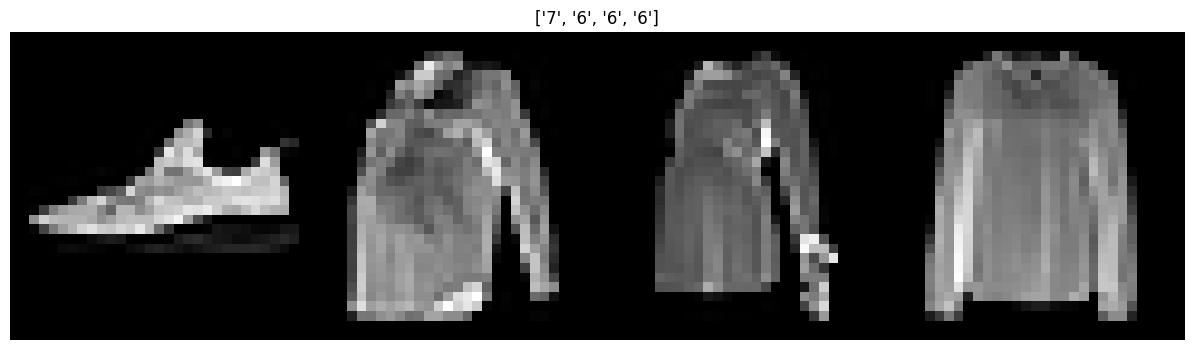

In [7]:
# 8-7 이미지 출력
images, labels = show_batch_images(trainloader)

In [8]:
# 8-8 배치 정규화가 적용되지 않은 네트워크
class NormalNet(nn.Module):
  def __init__(self):
    super(NormalNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [9]:
# 8-9 배치 정규화가 포함된 네트워크
class BNNet(nn.Module):
  def __init__(self):
    super(BNNet, self).__init__()
    self.classifier = nn.Sequential(
        nn.Linear(784, 48),
        nn.BatchNorm1d(48),
        nn.ReLU(),
        nn.Linear(48, 24),
        nn.BatchNorm1d(24),
        nn.ReLU(),
        nn.Linear(24, 10)
    )

  def forward(self, x):
    x = x.view(x.size(0), -1)
    x = self.classifier(x)
    return x

In [10]:
# 8-10 배치 정규화가 적용되지 않은 모델 선언
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [11]:
# 8-11 배치 정규화가 적용된 모델 선언
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [12]:
# 8-12 데이터셋 메모리로 불러오기
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, shuffle = True)

In [13]:
# 8-13 옵티마이저, 손실 함수 지정
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

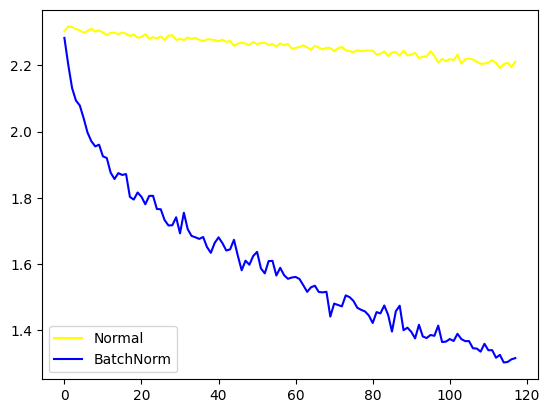

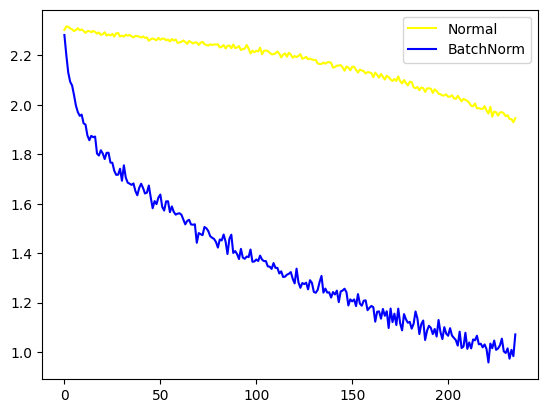

In [14]:
# 8-14 모델 학습
loss_arr = []
loss_bn_arr = []
max_epochs = 2

for epoch in range(max_epochs):
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    opt.zero_grad() # 배치 정규화가 적용되지 않은 모델의 학습
    outputs = model(inputs)
    loss = loss_fn(outputs, labels)
    loss.backward()
    opt.step()

    opt_bn.zero_grad() # 배치 정규화가 적용된 모델의 학습
    outputs_bn = model_bn(inputs)
    loss_bn = loss_fn(outputs_bn, labels)
    loss_bn.backward()
    opt_bn.step()

    loss_arr.append(loss.item())
    loss_bn_arr.append(loss_bn.item())

  plt.plot(loss_arr, 'yellow', label='Normal')
  plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
  plt.legend()
  plt.show()

In [15]:
# 8-15 데이터셋의 분포를 출력하기 위한 전처리
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

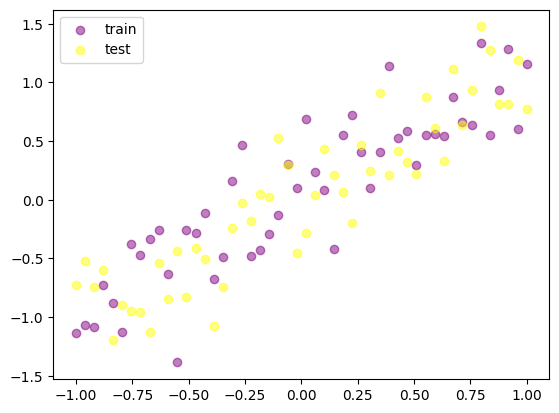

In [16]:
# 8-16 데이터 분포를 그래프로 출력
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c = 'purple',
            alpha = 0.5, label = 'train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c = 'yellow',
            alpha = 0.5, label = 'test')
plt.legend()
plt.show()

In [17]:
# 8-17 드롭아웃을 위한 모델 생성
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Dropout(p = 0.5),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용되지 않은 모델

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2), # 드롭아웃 적용
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
) # 드롭아웃이 적용된 모델

In [18]:
# 8-18 옵티마이저와 손실 함수 지정
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

/tmp/ipykernel_3992/4100747644.py:32: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %


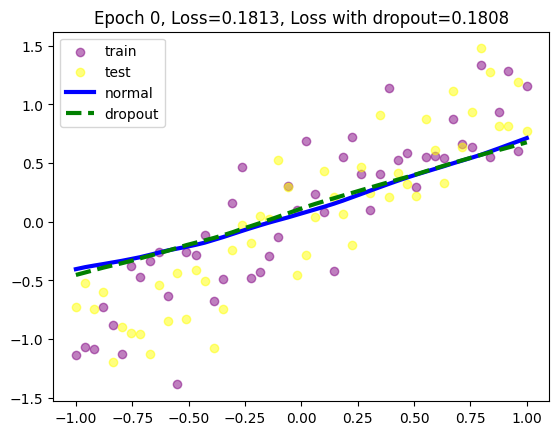

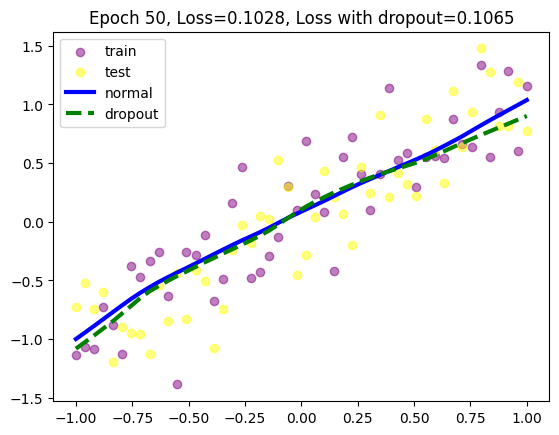

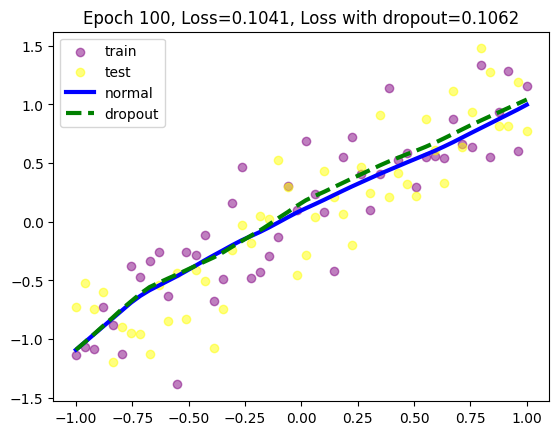

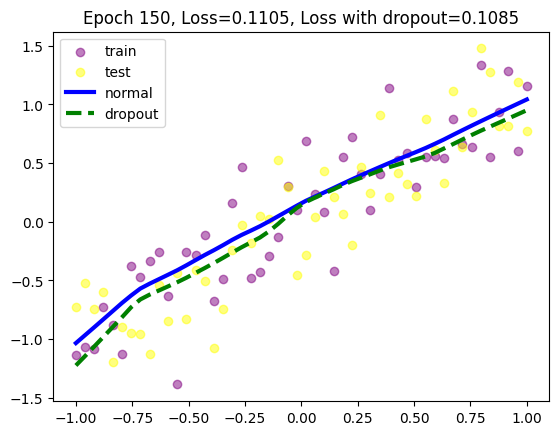

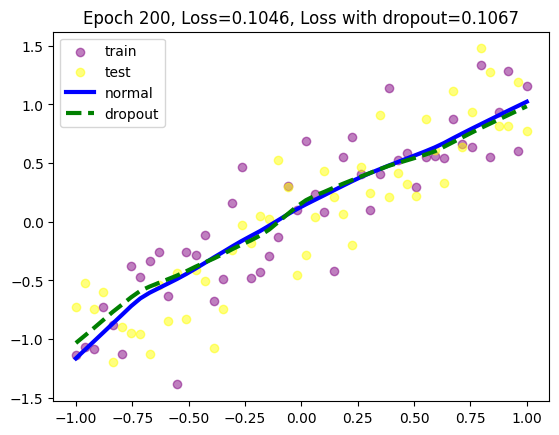

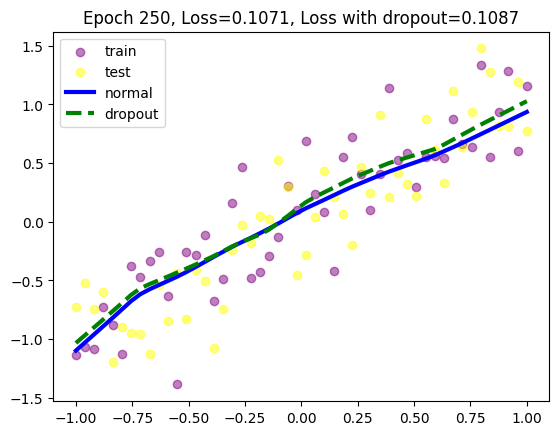

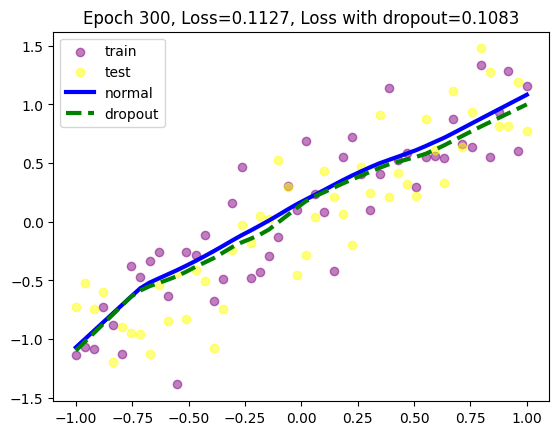

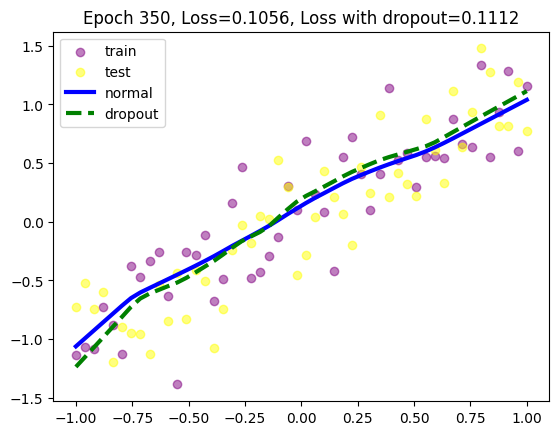

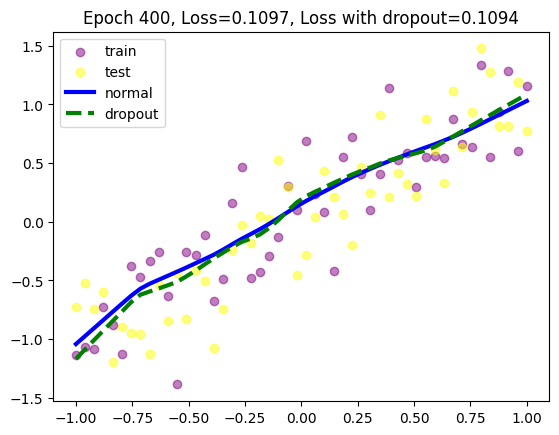

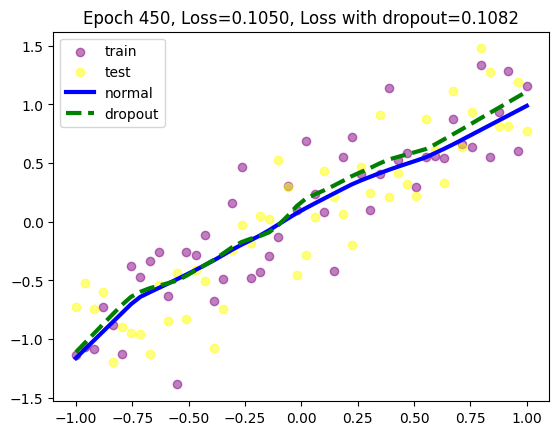

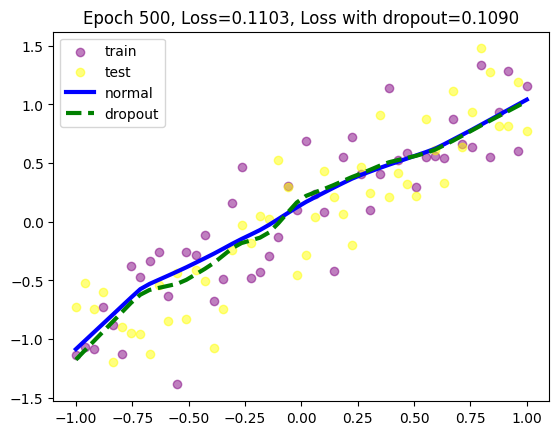

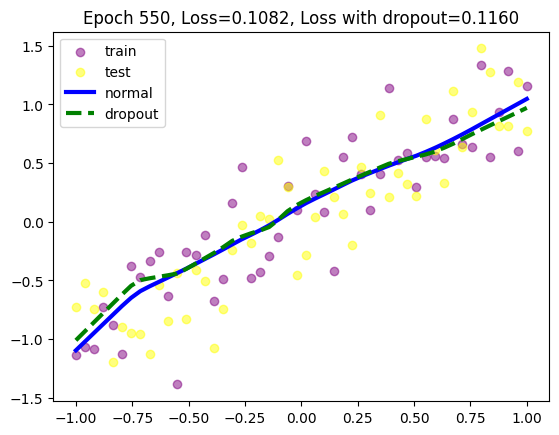

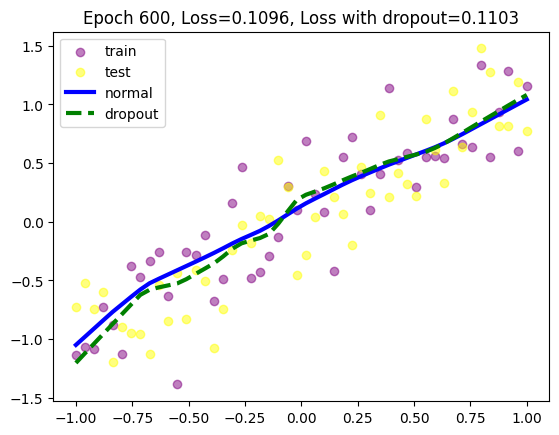

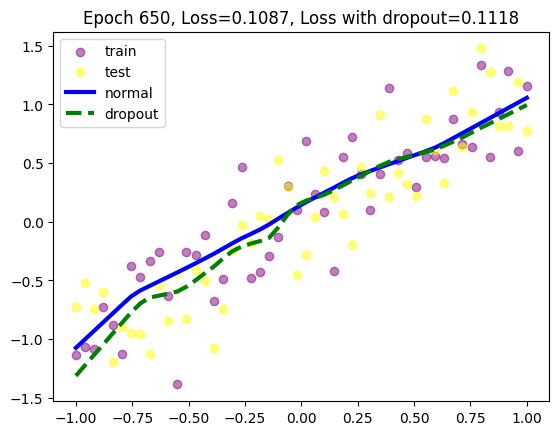

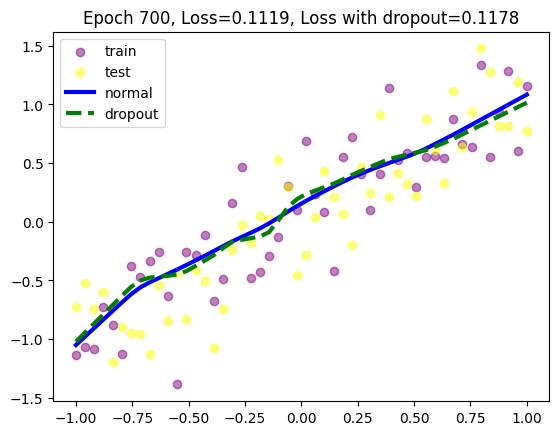

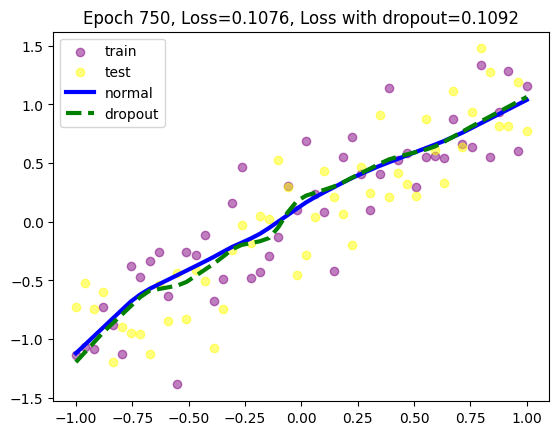

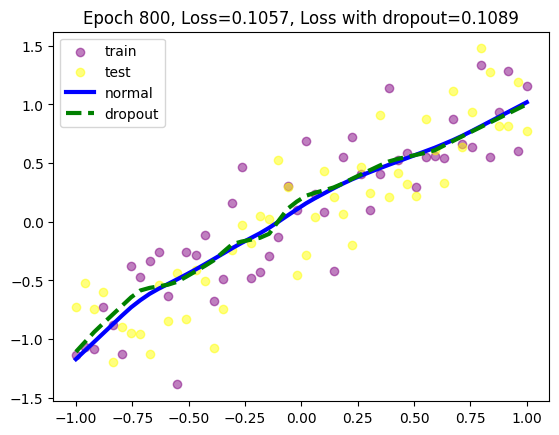

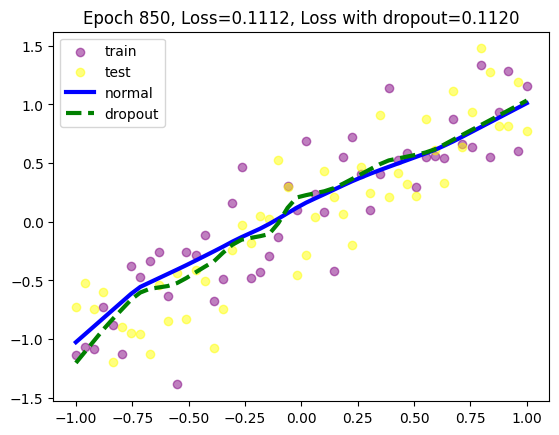

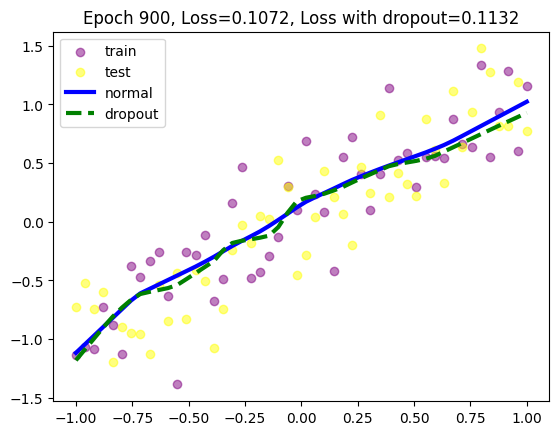

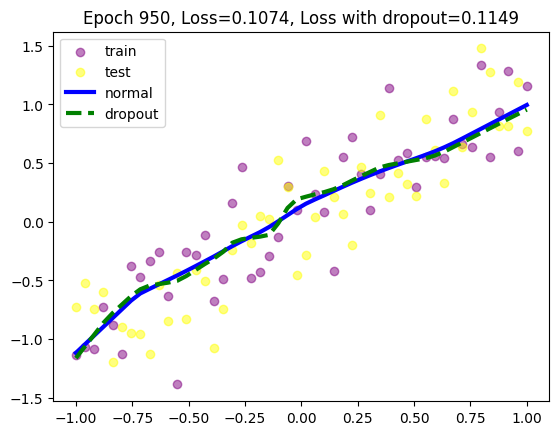

In [19]:
# 8-19 모델 학습
max_epochs = 1000
for epoch in range(max_epochs):
  pred = model(x_train) # 드롭아웃이 적용되지 않은 모델 학습
  loss = loss_fn(pred, y_train)
  opt.zero_grad()
  loss.backward()
  opt.step()

  pred_dropout = model_dropout(x_train) # 드롭아웃이 적용된 모델 학습
  loss_dropout = loss_fn(pred_dropout, y_train)
  opt_dropout.zero_grad()
  loss_dropout.backward()
  opt_dropout.step()

  if epoch % 50 == 0:
    model.eval()
    model_dropout.eval()

    test_pred = model(x_test)
    test_loss = loss_fn(test_pred, y_test)

    test_pred_dropout = model_dropout(x_test)
    test_loss_dropout = loss_fn(test_pred_dropout, y_test)

    plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c='purple',
                alpha=0.5, label='train')
    plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c='yellow',
                alpha=0.5, label='test')
    plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', lw=3, label='normal')
    plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', lw=3, label='dropout')
    plt.title('Epoch %d, Loss=%0.4f, Loss with dropout=%0.4f' %
              (epoch, test_loss, test_loss_dropout))
    plt.legend()
    model.train()
    model_dropout.train()
    plt.pause(0.05)

### 8.3.3 조기 종료를 이용한 성능 최적화

In [20]:
# 8-20 라이브러리 호출
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [21]:
# 8-21 데이터셋 전처리
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

In [22]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2278 (delta 3), reused 2 (delta 2), pack-reused 2262 (from 2)
Receiving objects: 100% (2278/2278), 330.29 MiB | 39.78 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [23]:
# 8-22 데이터셋 가져오기
train_dataset = datasets.ImageFolder(
    root=r'/content/080289/chap08/data/archive/train', # Changed from .csv to directory
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 32, shuffle = True,
)
val_dataset = datasets.ImageFolder(
    root =r'/content/080289/chap08/data/archive/test', # Changed from .csv to directory
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 32, shuffle = False,
)

In [24]:
# 8-23 모델 생성
def resnet50(pretrained=True, requires_grad=False):
  model = models.resnet50(progress=True, pretrained=pretrained)
  if requires_grad == False:
    for param in model.parameters():
      param.requires_grad = False
  elif requires_grad == True:
    for param in model.parameters():
      param.requires_grad = True

  model.fc = nn.LInear(2048, 2)
  return model

In [25]:
from torch.optim import optimizer
# 8-24 학습률 감소
class LRScheduler():
  def __init__(
      self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
  ):
      self.optimizer = optimizer
      self.patience = patience
      self.min_lr = min_lr
      self.factor = factor
      self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
          self.optimizer,
          mode = 'min',
          patience = self.patience,
          factor = self.factor,
          min_lr = self.min_lr,
          verbose = True
      )

  def __call__(self, val_loss):
    self.lr_scheduler.step(val_loss)

In [26]:
# 8-25 조기 종료
class EarlyStopping():
  def __init__(self, patience = 5, verbose=False, delta=0,
               path = '/content/080289/chap08/data/checkpoint.pt'):
    self.patience = patience
    self.verbose = verbose
    self.coutner = 0
    self.best_score = None
    self.early_stop = False
    self.val_loss_min = np.Inf
    self.delta = delta
    self.path = path

  def __call__(self, val_loss, model):
    score = -val_loss
    if self.best_score is None:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
    elif score < self.best_score + self.delta:
      self.counter += 1
      print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
      if self.counter >= self.patience:
        self.early_stop = True
    else:
      self.best_score = score
      self.save_checkpoint(val_loss, model)
      self.counter = 0

  def save_checkpoint(self, val_loss, model):
    if self.verbose:
      print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
    torch.save(model.state_dict(), self.path)
    self.val_loss_min = val_loss

In [27]:
# 8-26 인수 값 지정
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true')
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true')
args, unknown = parser.parse_known_args()
args = vars(args)

In [28]:
# 8-27 사전 훈련된 모델의 파라미터 확인
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")
total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 190MB/s]


25,557,032 total parameters.
25,557,032 training parameters.


In [29]:
# 8-28 옵티마이저와 손실 함수 지정
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr = lr)
criterion = nn.CrossEntropyLoss()

In [30]:
# 8-29 오차, 정확도 및 모델의 이름에 대한 문자열
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 저장하기 위한 문자열

In [31]:
# 8-30 오차, 정확도 및 모델의 이름에 대한 문자열
if args['lr_scheduler']:
  print('INFO: Initializing learning rate scheduler')
  lr_scheduler = LRScheduler(optimizer)
  loss_plot_name = 'lrs_loss'
  acc_plt_name = 'lrs_accuracy'
  model_name = 'lrs_model'
if args['early_stopping']:
  print('INFO: Initializing early stopping')
  early_stopping = EarlyStopping()
  loss_plot_name = 'es_loss'
  acc_plot_name = 'es_accuracy'
  model_name = 'es_model'

In [32]:
# 8-31 모델 학습 함수
def training(model, train_dataloader, train_dataset, optimizer, criterion):
  print('Training')
  model.train()
  train_running_loss = 0.0
  train_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(train_dataloader), total = int(len(train_dataset)/
                                                           train_dataloader.batch_size))
  for i, data in prog_bar:
    counter += 1
    data, target = data[0].to(device), data[1].to(device)
    total += target.size(0)
    optimizer.zero_grad()
    outputs = model(data)
    loss = criterion(outputs, target)
    train_running_loss += loss.item()
    _, preds = torch.max(outputs.data, 1)
    train_running_correct += (preds == target).sum().item()
    loss.backward()
    optimizer.step()

  train_loss = train_running_loss / counter
  train_accuracy = 100. * train_running_correct / total
  return train_loss, train_accuracy

In [33]:
# 8-32 모델 검증 함수
def validate(model, test_dataloader, val_dataset, criterion):
  print('Validating')
  model.eval()
  val_running_loss = 0.0
  val_running_correct = 0
  counter = 0
  total = 0
  prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/
                                                        test_dataloader.batch_size))
  with torch.no_grad():
    for i, data in prog_bar:
      counter += 1
      data, target = data[0].to(device), data[1].to(device)
      total += target.size(0)
      outputs = model(data)
      loss = criterion(outputs, target)

      val_running_loss += loss.item()
      _, preds = torch.max(outputs.data, 1)
      val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy

In [34]:
# 8-33 모델 학습
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

start = time.time()
for epoch in range(epochs):
  print(f"Epoch {epoch+1} of {epochs}")
  train_epoch_loss, train_epoch_accuracy = training(
      model, train_dataloader, train_dataset, optimizer, criterion
  )
  val_epoch_loss, val_epoch_accuracy = validate(
      model, val_dataloader, val_dataset, criterion
  )
  train_loss.append(train_epoch_loss)
  train_accuracy.append(train_epoch_accuracy)
  val_loss.append(val_epoch_loss)
  val_accuracy.append(val_epoch_accuracy)
  if args['lr_scheduler']:
    lr_scheduler(val_epoch_loss)
  if args['early_stopping']:
    early_stopping(val_epoch_loss, model)
    if early_stopping.early_stop:
      break
  print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
  print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
  end = time.time()
  print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:05,  2.67it/s]


Validating


16it [00:03,  4.07it/s]


Train Loss: 2.1566, Train Acc: 60.84
Val Loss: 99.0294, Val Acc: 49.40
Training time: 0.166 minutes
Epoch 2 of 100
Training


...

Train Loss: 0.0280, Train Acc: 99.60
Val Loss: 0.9751, Val Acc: 77.20
Training time: 14.763 minutes
Epoch 100 of 100
Training


16it [00:05,  3.01it/s]


Validating


16it [00:03,  4.55it/s]

Train Loss: 0.0136, Train Acc: 99.80
Val Loss: 1.0696, Val Acc: 73.20
Training time: 14.910 minutes


Saving loss and accuracy plots...


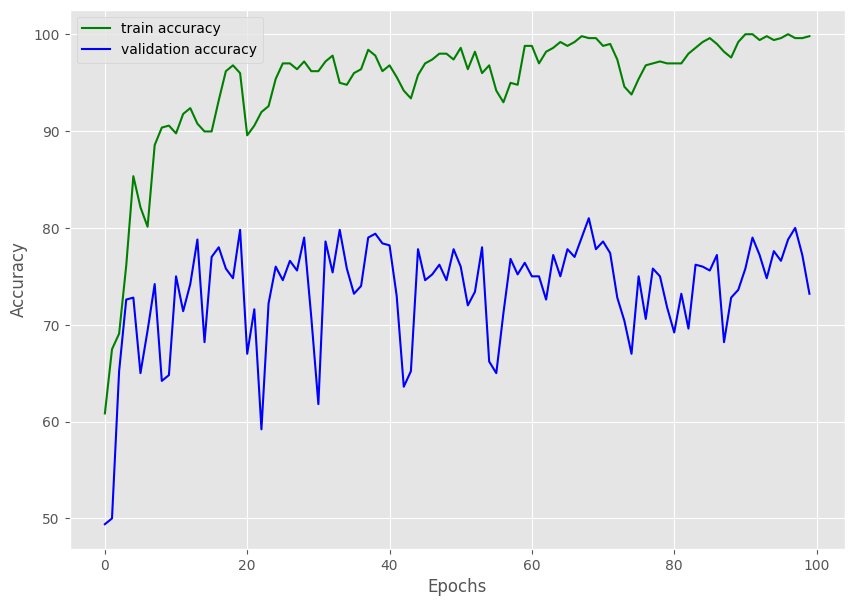

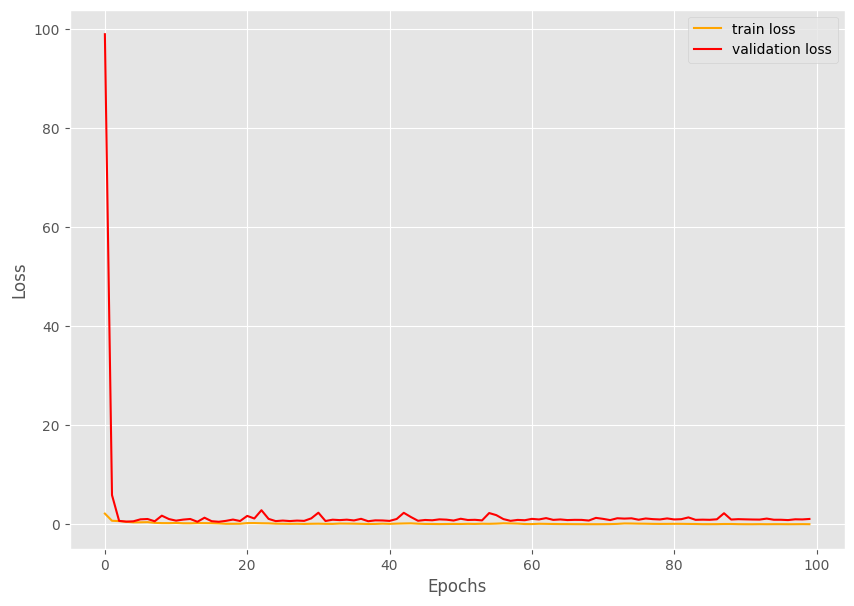

Saving model...
TRAINING COMPLETE


In [35]:
# 8-34 모델 학습 결과 출력
print('Saving loss and accuracy plots...')
plt.figure(figsize = (10, 7))
plt.plot(train_accuracy, color = 'green', label = 'train accuracy')
plt.plot(val_accuracy, color = 'blue', label = 'validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{acc_plot_name}.png')
plt.show()
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'train loss')
plt.plot(val_loss, color = 'red', label = 'validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f'/content/080289/chap08/data/{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'/content/080289/chap08/data/{model_name}.pt')
print('TRAINING COMPLETE')